In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [ ]:
df = pd.concat(
	[pd.read_csv(p) for p in Path("logs/experiments").glob("*csv")],
	ignore_index=True,
)
print(df.shape)
df.sample(5)

(67, 22)


,timestamp,run_name,step,train_loss,val_loss,loss_gap,val_perplexity,tokens_seen,tokens_per_second,step_time_ms,grad_norm,mps_allocated_mb,mps_driver_mb,parameters,parameter_memory_mb,device,batch_size,block_size,embd_dim,n_head,n_layer,learning_rate
41,2026-06-30T20:37:14,run_20260630_203641,500,2.241885,2.207686,-0.034199,9.094645,64000,2062.676357,62.055300,1.312625,52.777832,90.937500,3200576,12.209229,mps,4,32,256,4,4,0.001
4,2026-06-30T20:47:18,run_20260630_204553,2000,1.864702,2.020488,0.155786,7.542005,256000,3159.006340,40.519070,1.283544,50.598877,90.953125,3200576,12.209229,mps,4,32,256,2,4,0.001
2,2026-06-30T20:46:36,run_20260630_204553,1000,2.088734,2.129872,0.041137,8.413787,128000,3149.506618,40.641286,1.368757,50.598877,90.953125,3200576,12.209229,mps,4,32,256,2,4,0.001
3,2026-06-30T20:46:57,run_20260630_204553,1500,1.990297,2.127502,0.137205,8.393872,192000,3149.390386,40.642786,1.389985,50.598877,90.953125,3200576,12.209229,mps,4,32,256,2,4,0.001
44,2026-06-30T20:38:49,run_20260630_203641,2000,1.860260,2.027451,0.167191,7.594702,256000,2022.461768,63.289206,1.303372,52.777832,90.937500,3200576,12.209229,mps,4,32,256,4,4,0.001


label each run by config - for readability

In [3]:
df["cfg"] = (
	"block=" + df["block_size"].astype(str)
    + ", embd=" + df["embd_dim"].astype(str)
    + ", layers=" + df["n_layer"].astype(str)
    + ", heads=" + df["n_head"].astype(str)
)

df.cfg.sample(5)

11    block=32, embd=256, layers=6, heads=4
2     block=32, embd=256, layers=4, heads=2
58    block=32, embd=256, layers=4, heads=1
34     block=8, embd=384, layers=6, heads=8
50    block=32, embd=128, layers=4, heads=4
Name: cfg, dtype: str

## summary table

we want to answer:
- which model trained better and did it overfit?
- which model trained faster / used resources more efficiently?

In [4]:
summary = (
	df.sort_values("tokens_seen")
	.groupby(["cfg"])
	.agg(
		best_val_loss=("val_loss", "min"),
		final_val_loss=("val_loss", "last"),
		final_train_loss=("train_loss", "last"),
		final_loss_gap=("loss_gap", "last"),
		final_val_perplexity=("val_perplexity", "last"),	# optional: just more a more interpretable version of val loss

		max_tokens_seen=("tokens_seen", "max"),
		median_tokens_per_s=("tokens_per_second", "median"),

		parameters=("parameters", "first"),		# comparing model sizes
		parameter_memory_mb=("parameter_memory_mb", "first"),
		max_mps_allocated_mb=("mps_allocated_mb", "max")
	)
	.reset_index()
	.sort_values("best_val_loss")
)

# higher tokens_per_s = faster training throughput
# lower step_time_ms = faster steps

# NOTE: block_size affects tokens per step, so tokens_per_s is better than step_time_ms for comparing transformer configs

summary

,cfg,best_val_loss,final_val_loss,final_train_loss,final_loss_gap,final_val_perplexity,max_tokens_seen,median_tokens_per_s,parameters,parameter_memory_mb,max_mps_allocated_mb
3,"block=32, embd=256, layers=2, heads=4",1.934530,1.934530,1.875856,0.058674,6.920791,256000,3859.390793,1621056,6.183838,29.401367
5,"block=32, embd=256, layers=4, heads=2",2.020488,2.020488,1.864702,0.155786,7.542005,256000,3149.390386,3200576,12.209229,55.698975
7,"block=32, embd=256, layers=4, heads=8",2.023778,2.023778,1.868346,0.155432,7.566857,256000,1256.760093,3200576,12.209229,58.244141
6,"block=32, embd=256, layers=4, heads=4",2.027451,2.027451,1.860260,0.167191,7.594702,256000,2051.282660,3200576,12.209229,57.357910
1,"block=32, embd=128, layers=4, heads=4",2.036317,2.036317,1.833221,0.203096,7.662340,256000,2138.463463,813888,3.104736,16.224854
8,"block=32, embd=256, layers=6, heads=4",2.051404,2.051404,2.047226,0.004178,7.778817,256000,1410.861126,4780096,18.234619,85.302734
9,"block=32, embd=384, layers=6, heads=8",2.058080,2.144684,1.949562,0.195121,8.539340,384000,784.840413,10709056,40.851807,181.578369
2,"block=32, embd=128, layers=6, heads=8",2.084381,2.084381,1.972137,0.112244,8.039616,256000,871.850977,1210432,4.617432,26.528564
4,"block=32, embd=256, layers=4, heads=1",2.110833,2.110833,1.975203,0.135630,8.255112,256000,4255.329711,3200576,12.209229,56.616211
0,"block=16, embd=384, layers=6, heads=8",2.223586,2.223586,2.328996,-0.105410,9.240409,192000,387.748601,10702912,40.828369,171.976074


does making the model bigger help?

*NOTE: the following size charts are not as educational; better / more informative or educational causal variables are `block_size`, `embd_dim`, and `n_layer`*

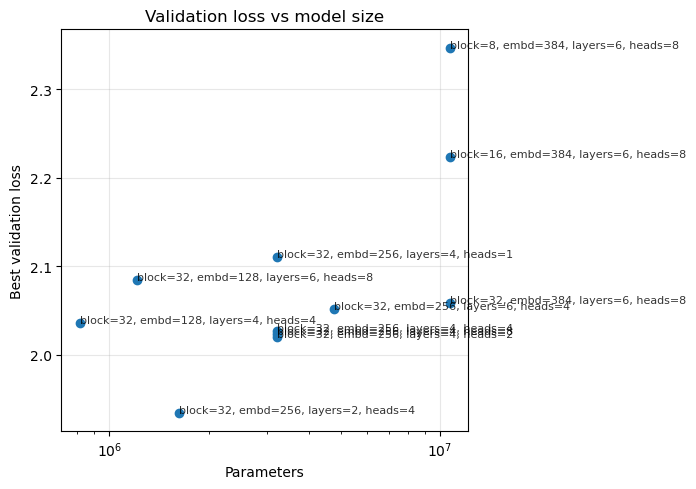

In [5]:
plt.figure(figsize=(7, 5))

plt.scatter(summary["parameters"], summary["best_val_loss"])

for _, r in summary.iterrows():
    plt.annotate(
        r["cfg"],
        (r["parameters"], r["best_val_loss"]),
        fontsize=8,
        alpha=0.8,
    )

plt.xscale("log")
plt.xlabel("Parameters")
plt.ylabel("Best validation loss")
plt.title("Validation loss vs model size")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

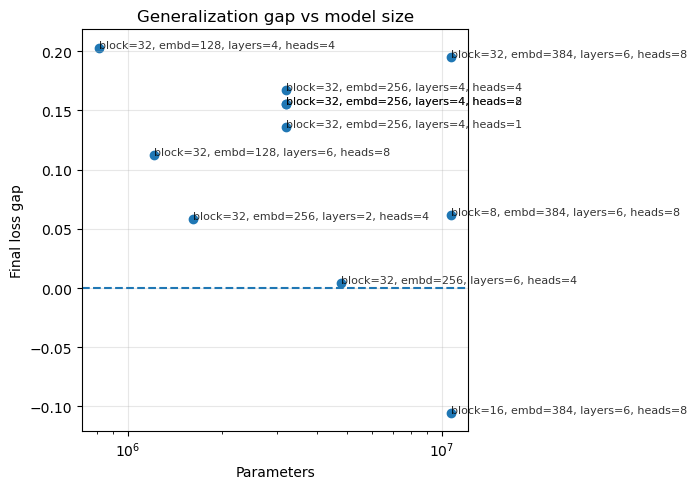

In [6]:
plt.figure(figsize=(7, 5))

plt.scatter(summary["parameters"], summary["final_loss_gap"])

for _, r in summary.iterrows():
    plt.annotate(
        r["cfg"],
        (r["parameters"], r["final_loss_gap"]),
        fontsize=8,
        alpha=0.8,
    )

plt.xscale("log")
plt.axhline(0, linestyle="--")
plt.xlabel("Parameters")
plt.ylabel("Final loss gap")
plt.title("Generalization gap vs model size")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

all the experiment configs:

- baseline:     block=8,  embd=384, layers=6, heads=8

- context:      block=16, embd=384, layers=6, heads=8
- context:      block=32, embd=384, layers=6, heads=8

- smaller C:    block=32, embd=128, layers=4, heads=4
- middle C:     block=32, embd=256, layers=4, heads=4

- layers low:   block=32, embd=256, layers=2, heads=4
- layers high:  block=32, embd=256, layers=6, heads=4

- heads:  block=32, embd=256, layers=4, heads=1/2/8

In [7]:
from dataclasses import dataclass

@dataclass
class Config:
	block_size: int | None = None
	embd_dim: int | None = None
	n_layer: int | None = None
	n_head: int | None = None

EXP_CONFIG = {
	"context": Config(
		embd_dim=384,
		n_layer=6,
		n_head=8
	),
	"embd_dim": Config(
		block_size=32,
		n_layer=4,
		n_head=4
	),
	"layers": Config(
		block_size=32,
		embd_dim=256,
		n_head=4
	),
	"heads": Config(
		block_size=32,
		embd_dim=256,
		n_layer=4
	)
}

then make separate plots by question / controlled variable:
- context length
- embedding size / dimension
- number of layers
- number of heads


In [8]:
%matplotlib widget

In [9]:
def _plot_train_val_loss(df: pd.DataFrame) -> None:
	plt.figure(figsize=(12, 8))

	# one colour per cfg
	cfgs = df.cfg.unique()
	colors = dict(zip(cfgs, plt.cm.tab10.colors[:len(cfgs)]))

	for cfg, g in df.sort_values("tokens_seen").groupby("cfg"):
		color = colors[cfg]
		plt.plot(g["tokens_seen"], g["train_loss"], marker="o", color=color, label=f"{cfg} train")
		plt.plot(g["tokens_seen"], g["val_loss"], marker="o", color=color, linestyle="--", label=f"{cfg} val")

	plt.xlabel("Tokens seen")
	plt.ylabel("Loss")
	plt.title("Train vs validation loss")
	plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
	plt.grid(True, alpha=0.3)
	plt.tight_layout()
	plt.show()

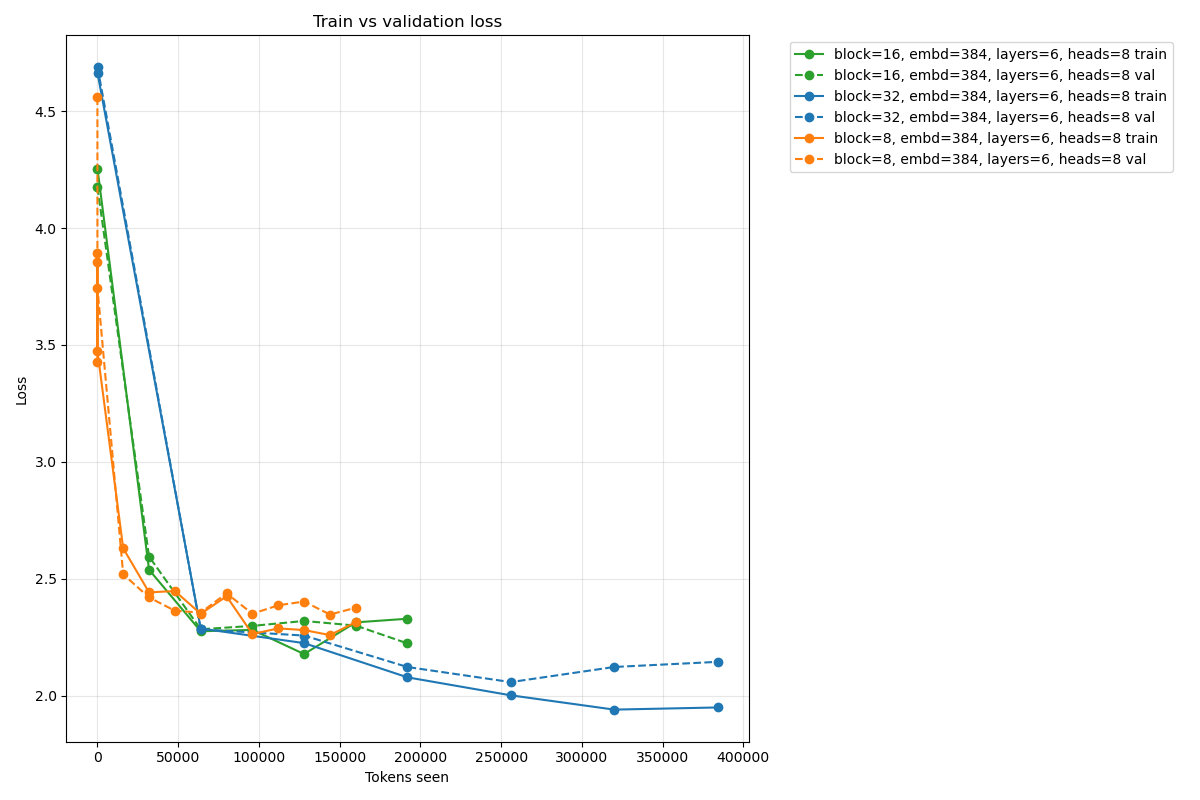

In [10]:
context_df = df[
	(df.embd_dim == EXP_CONFIG["context"].embd_dim)
	& (df.n_layer == EXP_CONFIG["context"].n_layer)
	& (df.n_head == EXP_CONFIG["context"].n_head)
].copy()

# def _add_experiment_label(df: pd.DataFrame, *, controlled_var: str) -> pd.DataFrame:
# 	df["label"] = f"{controlled_var}=" + df[f"{controlled_var}"].astype(str)
# 	return df

# context_df = _add_experiment_label(context_df, controlled_var="block_size")
_plot_train_val_loss(context_df)

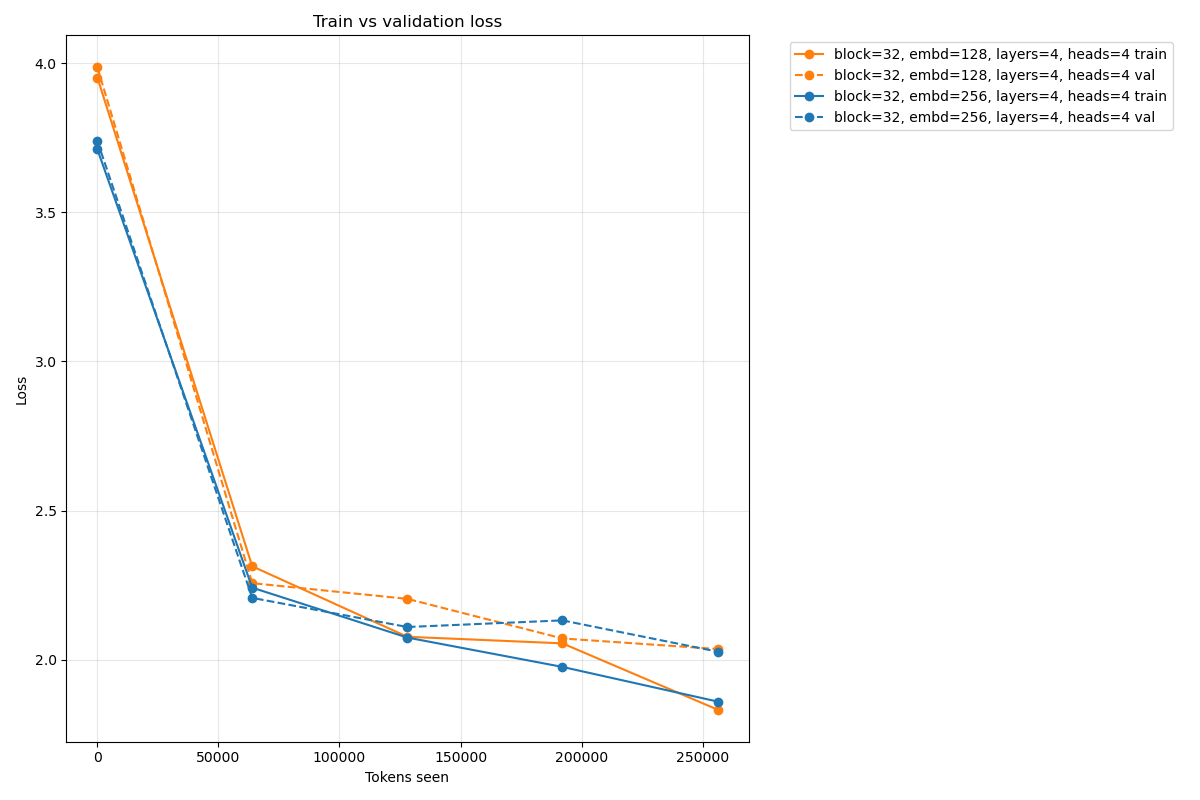

In [11]:
embd_df = df[
	(df.block_size == EXP_CONFIG["embd_dim"].block_size)
	& (df.n_layer == EXP_CONFIG["embd_dim"].n_layer)
	& (df.n_head == EXP_CONFIG["embd_dim"].n_head)
].copy()

_plot_train_val_loss(embd_df)

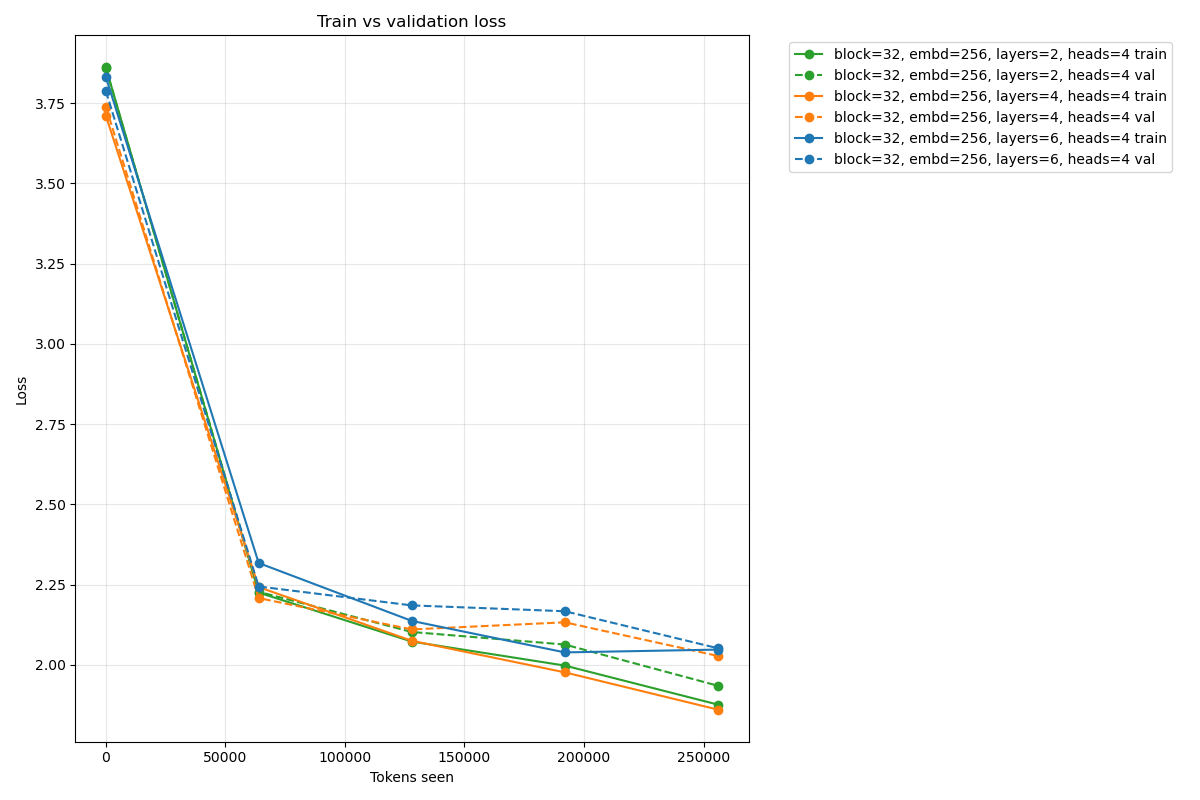

In [12]:
layers_df = df[
	(df.block_size == EXP_CONFIG["layers"].block_size)
	& (df.embd_dim == EXP_CONFIG["layers"].embd_dim)
	& (df.n_head == EXP_CONFIG["layers"].n_head)
].copy()

_plot_train_val_loss(layers_df)

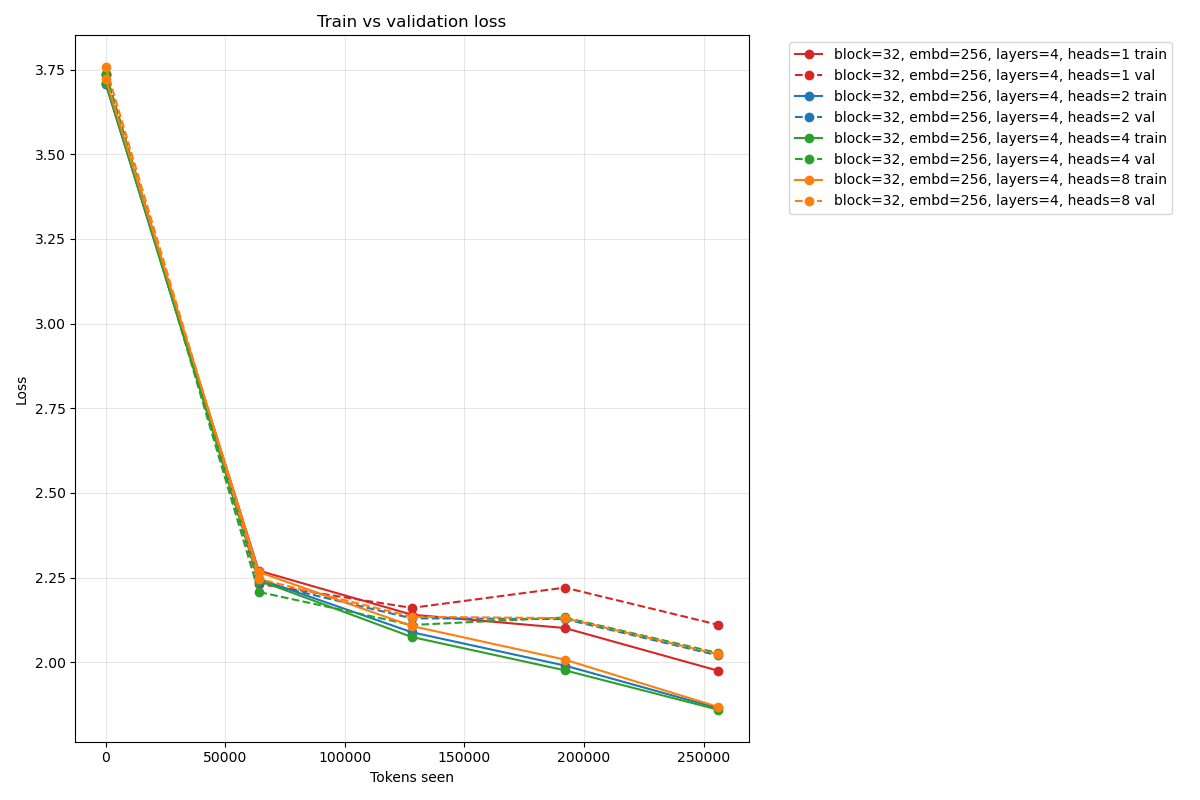

In [13]:
heads_df = df[
	(df.block_size == EXP_CONFIG["heads"].block_size)
	& (df.embd_dim == EXP_CONFIG["heads"].embd_dim)
	& (df.n_layer == EXP_CONFIG["heads"].n_layer)
].copy()

_plot_train_val_loss(heads_df)

rerun the best 2-3 configs longer (`max_iters=10000`), with `eval_iters=100`